# SABER Domain-Agnostic Evaluation Analysis

## Purpose

This notebook is a **domain-agnostic analysis framework** for any [SABER](../README.md) benchmark domain — Excytin, CyBench, CTI Realm, or any future domain you create. It parses `.eval` log files produced by `inspect eval` and generates comparative visualizations across models.

**What analyses are included?**

| # | Analysis | What it shows |
|---|----------|---------------|
| 1 | Overall Reward Distribution | Mean `saber_overall` score per model |
| 2 | Per-Group Breakdown *(domain-specific)* | Score grouped by domain-specific dimension — **requires `GROUP_FN`** |
| 3 | Cost Analysis | Total cost, cost/sample, and Pareto (score vs. cost) |
| 4 | Token Usage Breakdown | Input, output, cache, and reasoning tokens per model |
| 5 | Cost Efficiency | Reward per dollar — the production-readiness metric |
| 6 | Sub-Task Decomposition | Submission vs. checkpoint vs. aggregate scores |
| 7 | Checkpoint Distributions | Violin plots showing score spread per model |

> **Experiment 2 is domain-specific:** Each SABER domain groups tasks by a different dimension (incidents, challenge types, platforms, etc.). You must define a `GROUP_FN` for your domain — see the [Configuration](#configuration) section for examples. Set `GROUP_FN = None` to skip it entirely.

**For additional domain-specific analysis** (e.g., Excytin's per-incident submission vs. checkpoint gap heatmap), see the domain-specific notebooks:
- [`excytin_analysis.ipynb`](excytin_analysis.ipynb) — Excytin incident response

### How to use this notebook

1. **Edit the Configuration cell** (cell 4) to point at your domain's eval logs
2. **Define `GROUP_FN`** (cell 4) — build a grouping function for your domain's sample IDs (required for Experiment 2)
3. **Run All Cells** — every chart adapts to your configuration automatically

## Prerequisites & Running Evaluations

Before analyzing results, you need `.eval` log files. Here's the quick-start workflow:

### Install & Configure

```bash
# Install dependencies
uv sync --all-extras

# Configure credentials in .env
cp .env.template .env
# Set AZUREAI_OPENAI_API_KEY, ANTHROPIC_API_KEY, etc.
```

### Run an Evaluation

```bash
# Quick test (10 samples)
uv run inspect eval domains/<domain> --model <model_id> --limit 10

# Full evaluation
uv run inspect eval domains/<domain> --model <model_id>

# Examples:
uv run inspect eval domains/excytin --model anthropic/claude-sonnet-4-6
uv run inspect eval domains/cybench --model openai/azure/gpt-5.4
```

### View Results Interactively

**VS Code:** Install the **Inspect AI** extension → click any `.eval` file to browse samples, scores, and conversations.

**Browser:** `uv run inspect view` → opens a dashboard at http://localhost:7575 with log list, score summaries, and sample explorer.

### Organize Logs for This Notebook

Copy eval logs to `latest_experiments/<domain>/` with descriptive names:
```
latest_experiments/<domain>/
  model_a_test_set.eval
  model_b_test_set.eval
  model_b_test_set_no_reasoning.eval   # optional baseline
```

See [README.md](../README.md) for full installation, agent options, and `-T` parameter reference.

<a id="configuration"></a>
## Configuration

Edit the cell below to configure this notebook for **your domain and models**.

### Adding your own models

1. Run your evaluation and save the `.eval` file to `latest_experiments/<domain>/`
2. Add an entry to `EVAL_LOGS`: `'Display Name': 'filename.eval'`
3. Add a color in `COLORS`: `'Display Name': '#HexColor'`
4. Add pricing in `PRICING`: `'api/model-id': {input, output, cache_read, cache_write}`
5. *(Optional)* Add a no-reasoning baseline to `NO_THINKING_LOGS`

### Building a `GROUP_FN` for your domain *(required for Experiment 2)*

Experiment 2 (Per-Group Breakdown) is a **domain-specific** analysis — each SABER domain groups tasks by a different dimension. You must define a `GROUP_FN` that extracts a group label from each sample ID.

Each domain encodes its grouping dimension in the sample ID:

| Domain | Sample ID Example | Group Dimension | `GROUP_FN` |
|--------|-------------------|-----------------|------------|
| Excytin | `incident_5_latest_test_set_task_42` | Security incident | `'_'.join(id.split('_')[:2])` → `incident_5` |
| CyBench | `labyrinth_linguist_task_hard` | Challenge type | `'_'.join(id.split('_')[:-2])` → `labyrinth_linguist` |
| CTI Realm | `linux_001` | Platform/OS | `id.split('_')[0]` → `linux` |

**When adding a new domain**, inspect a few sample IDs from your `.eval` files and write a `GROUP_FN` that extracts the meaningful dimension. Set `GROUP_FN = None` to skip per-group analysis entirely.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Edit this cell for your domain and models
# ══════════════════════════════════════════════════════════════════════════════
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# Ensure saber_analysis is importable (notebook lives in notebooks/)
NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_baseline_logs, ensure_eval_files
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

# ── Domain ──
DOMAIN_NAME = 'Excytin'  # Display name for chart titles
DOMAIN_SLUG = 'excytin'  # Subfolder name in eval_samples/ and on HuggingFace
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
LOG_DIR = str(REPO_ROOT / 'eval_samples' / DOMAIN_SLUG)  # Path to .eval files
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# MODEL REGISTRY — {Display Name: filename.eval}
# ══════════════════════════════════════════════════════════════════════════════
EVAL_LOGS = {
    'Claude Haiku 4.5':  'haiku_4.5_latest_test_set.eval',
    'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set.eval',
    'Claude Opus 4.6':   'opus_4.6_latest_test_set.eval',
    'GPT-5.4':           'gpt_5.4_latest_test_set.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set.eval',
}

# Optional: baseline runs WITHOUT extended reasoning
NO_THINKING_LOGS = {
    'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set_no_thinking.eval',
    'Claude Opus 4.6':   'opus_4.6_latest_test_set_no_thinking.eval',
    'GPT-5.4':           'gpt_5.4_latest_test_set_no_reasoning.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set_no_reasoning.eval',
}

COLORS = {
    'Claude Haiku 4.5':  '#1ABC9C',
    'Claude Sonnet 4.6': '#F39C12',
    'Claude Opus 4.6':   '#E74C3C',
    'GPT-5.4':           '#27AE60',
    'GPT-5.4-mini':      '#2E86C1',
}

N_SAMPLES = 599  # Total samples in your eval (must be same for all models)
MODEL_ORDER = list(EVAL_LOGS.keys())

# ══════════════════════════════════════════════════════════════════════════════
# GROUPING — How to group samples for per-group analysis (Section 2)
#
# Set GROUP_FN to a function: sample_id (str) → group_label (str)
# Set GROUP_FN = None to skip per-group analysis entirely.
#
# Examples for each domain:
#   Excytin:   lambda sid: '_'.join(sid.split('_')[:2])       # → 'incident_5'
#   CyBench:   lambda sid: '_'.join(sid.split('_')[:-2])      # → 'labyrinth_linguist'
#   CTI Realm: lambda sid: sid.split('_')[0]                  # → 'linux'
# ══════════════════════════════════════════════════════════════════════════════
GROUP_FN = lambda sid: '_'.join(sid.split('_')[:2])  # Excytin: group by incident
GROUP_LABEL = 'Incident'  # Label used in chart titles/axes

# ══════════════════════════════════════════════════════════════════════════════
# PRICING — {api_model_id: {input, output, cache_read, cache_write}} $/1M tokens
# ══════════════════════════════════════════════════════════════════════════════
PRICING = {
    'anthropic/claude-haiku-4-5':            {'input': 0.80,  'output': 4.00,  'cache_read': 0.08,   'cache_write': 1.00},
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
    'anthropic/claude-opus-4-6':             {'input': 15.00, 'output': 75.00, 'cache_read': 1.875,  'cache_write': 18.75},
    'openai/azure/gpt-5.4':                  {'input': 10.00, 'output': 30.00, 'cache_read': 2.50,   'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini-2026-03-17':  {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
}

# ══════════════════════════════════════════════════════════════════════════════
# ENSURE EVAL FILES — downloads from HuggingFace if not available locally.
# Checks LOG_DIR first, then latest_experiments/ as fallback, then HuggingFace.
# ══════════════════════════════════════════════════════════════════════════════
ensure_eval_files(
    EVAL_LOGS, LOG_DIR, DOMAIN_SLUG,
    baseline_logs=NO_THINKING_LOGS,
    fallback_dirs=[str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG)],
)

print(f'✓ Domain: {DOMAIN_NAME}')
print(f'  Models: {len(EVAL_LOGS)} ({", ".join(MODEL_ORDER)})')
print(f'  Samples: {N_SAMPLES}')
print(f'  Log dir: {LOG_DIR}')

✓ All 9 eval files found locally in /home/amudgerikar/repos/oss_saber/latest_experiment_samples/excytin
✓ Domain: Excytin
  Models: 5 (Claude Haiku 4.5, Claude Sonnet 4.6, Claude Opus 4.6, GPT-5.4, GPT-5.4-mini)
  Samples: 599
  Log dir: /home/amudgerikar/repos/oss_saber/latest_experiment_samples/excytin


## Data Loading

Parses all `.eval` ZIP archives and extracts:
- **`saber_overall`** per sample — the primary benchmark metric
- **Sub-task scores** — submission, checkpoint_N, aggregate per sample
- **Group labels** — derived from sample IDs using `GROUP_FN`

`.eval` files are ZIP archives containing `header.json` (run metadata, overall scores) and `samples/*.json` (per-sample conversations and scores).

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING — Parses eval logs into DataFrames
# ══════════════════════════════════════════════════════════════════════════════
samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
    EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN
)

baseline_samples_df, baseline_subtasks_df, no_thinking_overall = load_baseline_logs(
    NO_THINKING_LOGS, LOG_DIR, group_fn=GROUP_FN
)

print(f'\n✓ Loaded {len(samples_df)} sample scores across {samples_df["model"].nunique()} models')
print(f'✓ Loaded {len(subtasks_df)} sub-task scores')
print(f'✓ Loaded {len(baseline_samples_df)} baseline sample scores')
if GROUP_FN:
    print(f'✓ Groups: {sorted(samples_df["group"].unique())}')
print()
print('═══ Overall SABER Scores (with extended reasoning) ═══')
for m in MODEL_ORDER:
    if m in model_overall:
        r = overall_df.loc[m]
        print(f'  {m:25s}  mean={r["mean"]:.4f}  stderr={r["stderr"]:.4f}')
print()
print('═══ Baseline Scores (without extended reasoning) ═══')
for m, r in no_thinking_overall.items():
    if m in model_overall:
        delta = model_overall[m]['mean'] - r['mean']
        print(f'  {m:25s}  baseline={r["mean"]:.4f}  with_reasoning={model_overall[m]["mean"]:.4f}  delta={delta:+.4f}')


✓ Loaded 2995 sample scores across 5 models
✓ Loaded 12985 sub-task scores
✓ Loaded 2396 baseline sample scores
✓ Groups: ['incident_134', 'incident_166', 'incident_322', 'incident_34', 'incident_38', 'incident_39', 'incident_5', 'incident_55']

═══ Overall SABER Scores (with extended reasoning) ═══
  Claude Haiku 4.5           mean=0.8381  stderr=0.0125
  Claude Sonnet 4.6          mean=0.8567  stderr=0.0116
  Claude Opus 4.6            mean=0.8649  stderr=0.0115
  GPT-5.4                    mean=0.8752  stderr=0.0106
  GPT-5.4-mini               mean=0.8265  stderr=0.0145

═══ Baseline Scores (without extended reasoning) ═══
  Claude Sonnet 4.6          baseline=0.8222  with_reasoning=0.8567  delta=+0.0345
  Claude Opus 4.6            baseline=0.8745  with_reasoning=0.8649  delta=-0.0096
  GPT-5.4                    baseline=0.8044  with_reasoning=0.8752  delta=+0.0708
  GPT-5.4-mini               baseline=0.7442  with_reasoning=0.8265  delta=+0.0824


---

## 1. Overall Reward Distribution per Model

### What this measures

The **mean `saber_overall` score** across all samples for each model. This is SABER's primary metric — a weighted combination of submission correctness and checkpoint completeness.

### How to read the chart

- **Solid bars** = score with default settings (no extended reasoning)
- **Hatched overlay** = additional score from extended reasoning (`reasoning_effort=high`)
- **Error bars** = standard error — overlapping bars mean the difference may not be significant
- Higher is better (max = 1.0)

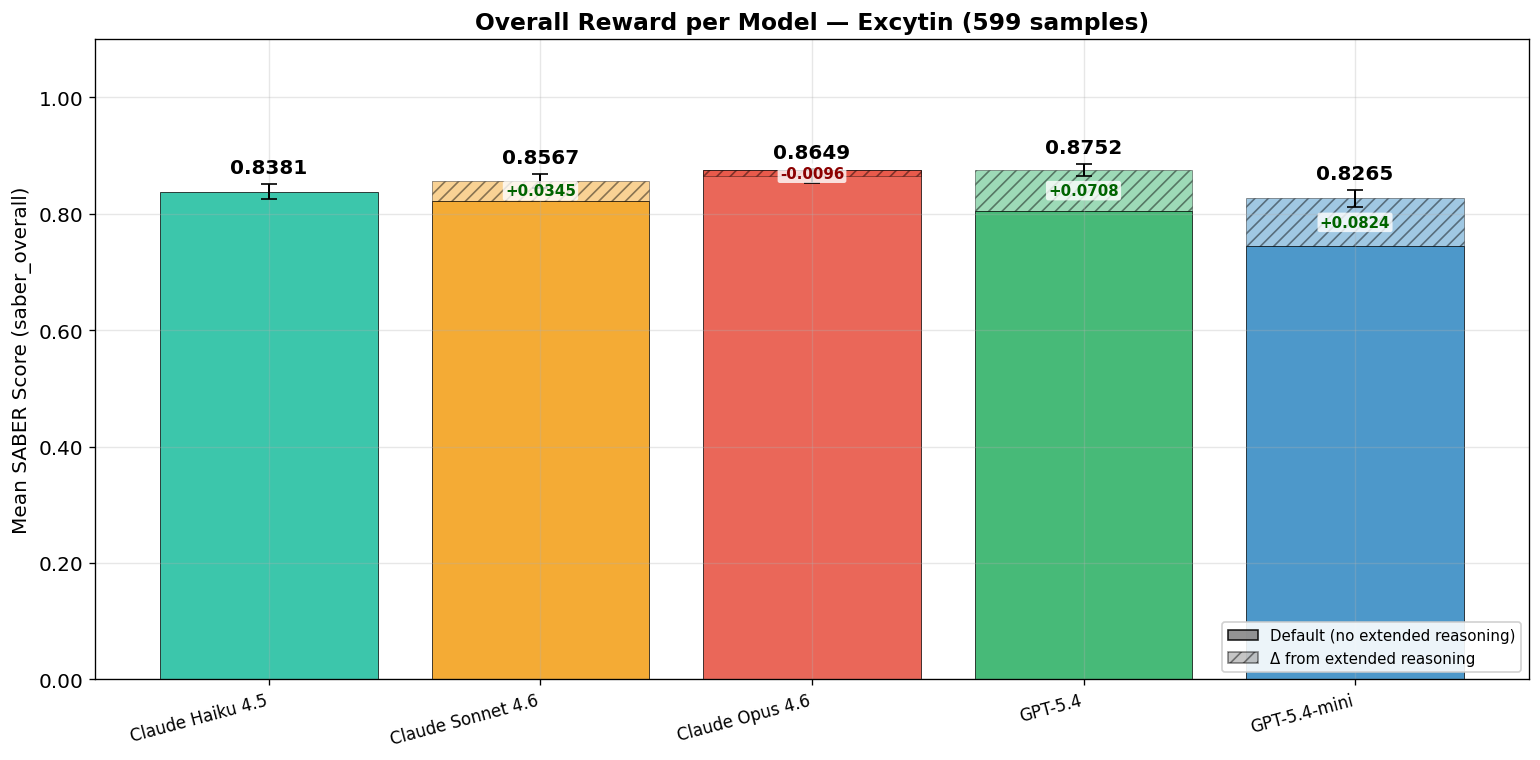

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Overall mean scores bar chart
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6.5))
means = [overall_df.loc[m, 'mean'] for m in MODEL_ORDER]
stderrs = [overall_df.loc[m, 'stderr'] for m in MODEL_ORDER]
colors = [COLORS[m] for m in MODEL_ORDER]

base_heights, delta_heights = [], []
for m in MODEL_ORDER:
    if m in no_thinking_overall:
        base_heights.append(no_thinking_overall[m]['mean'])
        delta_heights.append(overall_df.loc[m, 'mean'] - no_thinking_overall[m]['mean'])
    else:
        base_heights.append(overall_df.loc[m, 'mean'])
        delta_heights.append(0.0)

x = np.arange(len(MODEL_ORDER))
ax.bar(x, base_heights, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
for i, m in enumerate(MODEL_ORDER):
    if delta_heights[i] != 0:
        ax.bar(i, abs(delta_heights[i]),
               bottom=base_heights[i] if delta_heights[i] > 0 else base_heights[i] + delta_heights[i],
               color=colors[i], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)
for i, (mean, se) in enumerate(zip(means, stderrs)):
    ax.text(i, mean + se + 0.012, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
for i, m in enumerate(MODEL_ORDER):
    if m in no_thinking_overall:
        d = delta_heights[i]
        mid_y = base_heights[i] + d / 2
        color_text = '#006400' if d > 0 else '#8B0000'
        ax.text(i, mid_y, f'{d:+.4f}', ha='center', va='center', fontsize=9, fontweight='bold',
                color=color_text, bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score (saber_overall)')
ax.set_title(f'Overall Reward per Model — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
solid_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default (no extended reasoning)')
hatch_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ from extended reasoning')
ax.legend(handles=[solid_patch, hatch_patch], loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'overall_reward.png', bbox_inches='tight')
plt.show()

---

## 2. Per-Group Breakdown *(Domain-Specific)*

### What this measures

Scores broken down by the **grouping dimension** configured in `GROUP_FN`. This is a **domain-specific experiment** — each SABER domain groups tasks differently, and you must define a `GROUP_FN` that maps sample IDs to group labels for your domain.

| Domain | Group Dimension | `GROUP_FN` |
|--------|-----------------|------------|
| **Excytin** | Security incident (8 incidents, ~72 tasks each) | `'_'.join(id.split('_')[:2])` |
| **CyBench** | Challenge type | `'_'.join(id.split('_')[:-2])` |
| **CTI Realm** | Platform/OS | `id.split('_')[0]` |

### How to read the chart

- Each cluster = one group; bars = models
- Task counts shown below each group name
- Hatched overlays = reasoning delta

> **Note:** If you set `GROUP_FN = None` in the Configuration cell, this section is skipped.

═══ Per-Incident Mean Scores ═══
model         Claude Haiku 4.5  Claude Sonnet 4.6  Claude Opus 4.6  GPT-5.4  GPT-5.4-mini
group                                                                                    
incident_134            0.9138             0.9569           0.9655   0.9828        0.9655
incident_166            0.8391             0.8563           0.8851   0.9425        0.8736
incident_322            0.8874             0.8626           0.8962   0.8904        0.8406
incident_34             0.9294             0.9353           0.9471   0.9412        0.9647
incident_38             0.9167             0.8333           0.8750   0.9167        0.9167
incident_39             0.8142             0.8042           0.8442   0.8033        0.7900
incident_5              0.7842             0.8308           0.8000   0.8058        0.7083
incident_55             0.7562             0.8100           0.7858   0.8258        0.7233

  incident_134: 58 tasks
  incident_166: 87 tasks
  incident_322: 

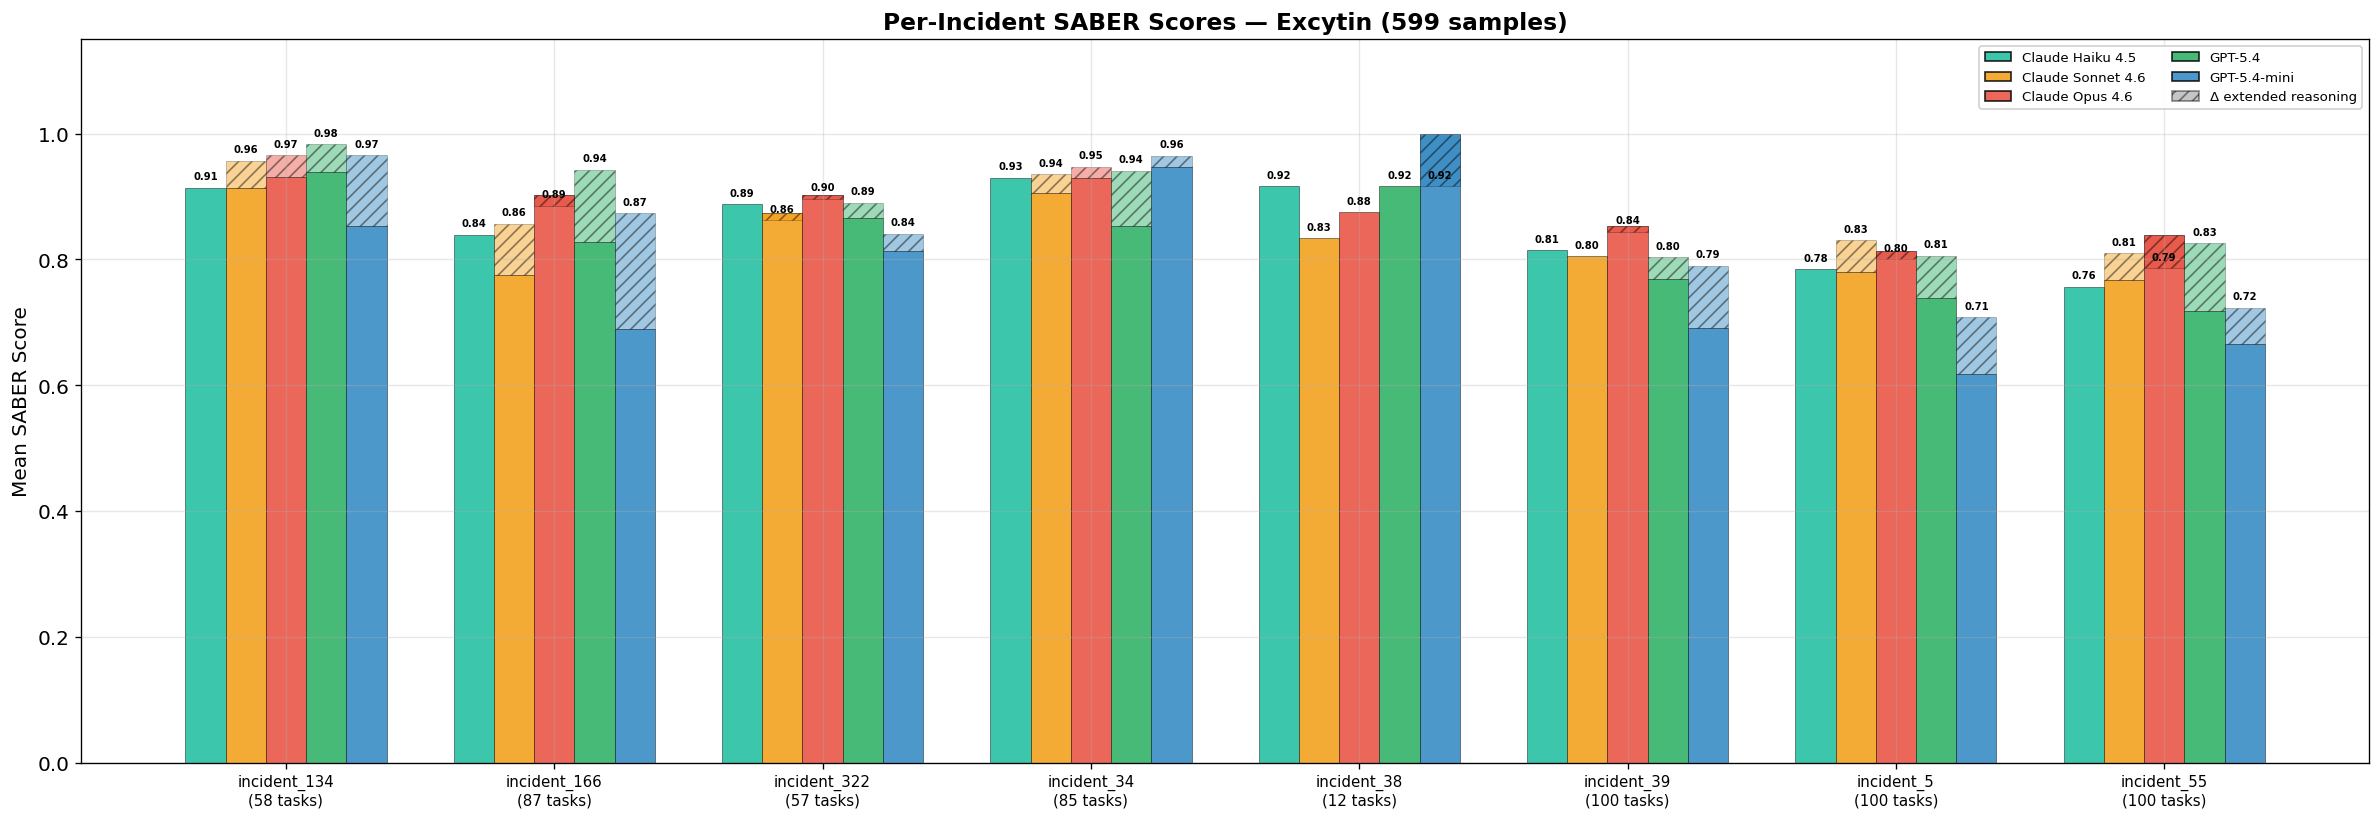

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-group breakdown (configurable grouping dimension)
# ══════════════════════════════════════════════════════════════════════════════
if GROUP_FN is None:
    print('⏭ Per-group analysis skipped (GROUP_FN is None)')
else:
    group_scores = samples_df.groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER)
    group_scores = group_scores.sort_index()
    group_counts = samples_df[samples_df['model'] == MODEL_ORDER[0]].groupby('group').size()

    baseline_group = pd.DataFrame()
    if len(baseline_samples_df) > 0:
        baseline_group = baseline_samples_df.groupby(['group', 'model'])['score'].mean().unstack('model')
        baseline_group = baseline_group.reindex(index=group_scores.index, columns=MODEL_ORDER)

    print(f'═══ Per-{GROUP_LABEL} Mean Scores ═══')
    print(group_scores.round(4).to_string())
    print()
    for grp, cnt in group_counts.items():
        print(f'  {grp}: {cnt} tasks')

    fig, ax = plt.subplots(figsize=(max(14, len(group_scores) * 2.5), 7))
    n_groups = len(group_scores)
    n_models = len(MODEL_ORDER)
    bar_width = min(0.15, 0.8 / n_models)
    xg = np.arange(n_groups)

    for i, model in enumerate(MODEL_ORDER):
        offset = (i - n_models/2 + 0.5) * bar_width
        full_vals = group_scores[model].values
        has_baseline = (model in no_thinking_overall and len(baseline_group) > 0
                        and model in baseline_group.columns)

        if has_baseline:
            base_vals = baseline_group[model].values
            ax.bar(xg + offset, base_vals, bar_width, color=COLORS[model],
                   edgecolor='black', linewidth=0.3, alpha=0.85)
            for xi_idx in range(len(xg)):
                d = full_vals[xi_idx] - base_vals[xi_idx]
                if abs(d) > 0.001:
                    ax.bar(xg[xi_idx] + offset, abs(d),
                           bottom=base_vals[xi_idx] if d > 0 else full_vals[xi_idx],
                           width=bar_width, color=COLORS[model],
                           edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
        else:
            ax.bar(xg + offset, full_vals, bar_width, color=COLORS[model],
                   edgecolor='black', linewidth=0.3, alpha=0.85)

        for xi, v in zip(xg, full_vals):
            ax.text(xi + offset, v + 0.01, f'{v:.2f}', ha='center', va='bottom',
                    fontsize=6, fontweight='bold')

    handles = [mpatches.Patch(facecolor=COLORS[m], edgecolor='black', alpha=0.85, label=m) for m in MODEL_ORDER]
    handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9, ncol=2)

    ax.set_xticks(xg)
    labels = [f'{grp}\n({group_counts.get(grp, "?")} tasks)' for grp in group_scores.index]
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Mean SABER Score')
    ax.set_title(f'Per-{GROUP_LABEL} SABER Scores — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold')
    ax.set_ylim(0, 1.15)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'per_{GROUP_LABEL.lower()}_scores.png', bbox_inches='tight')
    plt.show()

---

## 3. Cost Analysis

### What this measures

Quantifies **total cost**, **cost per sample**, and **score-cost tradeoffs** for each model using token counts from eval logs and published API pricing.

### Charts

1. **Total Eval Cost** — absolute dollar cost of the full benchmark run
2. **Cost per Sample** — average cost per task (useful for budgeting)
3. **Score vs. Cost (Pareto)** — upper-left = best value; arrows show the cost of enabling reasoning

> **To add pricing for your model:** Update `PRICING` in the Configuration cell.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3a: Token usage & cost extraction
# ══════════════════════════════════════════════════════════════════════════════
cost_df = pd.DataFrame(extract_cost_rows(EVAL_LOGS, LOG_DIR, PRICING, N_SAMPLES)).set_index('model').reindex(MODEL_ORDER)
_baseline_rows = extract_cost_rows(NO_THINKING_LOGS, LOG_DIR, PRICING, N_SAMPLES)
baseline_cost_df = pd.DataFrame(_baseline_rows).set_index('model') if _baseline_rows else pd.DataFrame()

print('═══ Cost Breakdown (with extended reasoning) ═══')
print(cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
if len(baseline_cost_df) > 0:
    print()
    print('═══ Cost Breakdown (default / no reasoning) ═══')
    print(baseline_cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
print()
print('═══ Token Usage (with extended reasoning) ═══')
token_cols = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens', 'total_tokens']
print(cost_df[token_cols].to_string())

═══ Cost Breakdown (with extended reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Haiku 4.5    0.84       34.95             0.06
Claude Sonnet 4.6   0.86      120.48             0.20
Claude Opus 4.6     0.86      441.78             0.74
GPT-5.4             0.88      671.79             1.12
GPT-5.4-mini        0.83      117.78             0.20

═══ Cost Breakdown (default / no reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Sonnet 4.6   0.82       79.70             0.13
Claude Opus 4.6     0.87      429.37             0.72
GPT-5.4             0.80      254.77             0.43
GPT-5.4-mini        0.74       54.75             0.09

═══ Token Usage (with extended reasoning) ═══
                   input_tokens  output_tokens  cache_read  cache_write  reasoning_tokens  total_tokens
model                                            

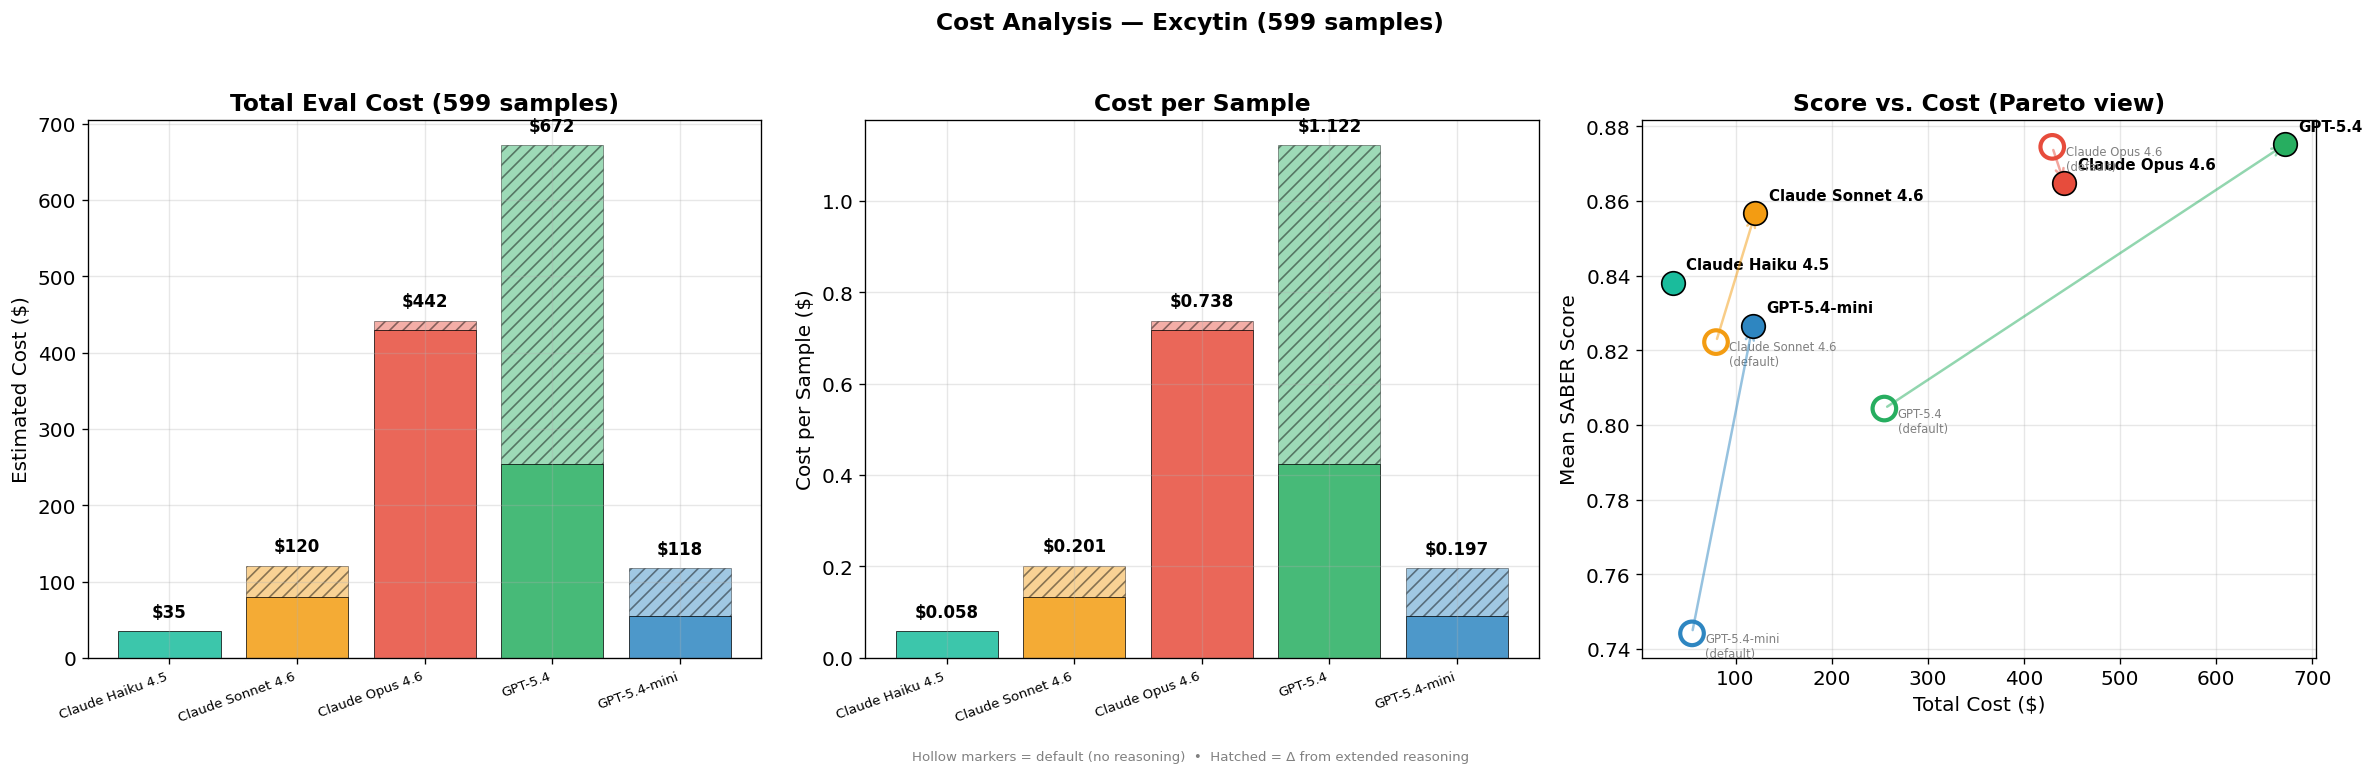

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3b: Cost visualization — total, per-sample, Pareto
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(MODEL_ORDER))

# Panel 1: Total cost
ax = axes[0]
for i, m in enumerate(MODEL_ORDER):
    tc = cost_df.loc[m, 'total_cost']
    if m in baseline_cost_df.index:
        base_tc = baseline_cost_df.loc[m, 'total_cost']
        ax.bar(i, base_tc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        delta_tc = tc - base_tc
        ax.bar(i, abs(delta_tc), bottom=base_tc if delta_tc > 0 else tc,
               color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, tc, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, tc + cost_df['total_cost'].max()*0.02, f'${tc:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Estimated Cost ($)'); ax.set_title(f'Total Eval Cost ({N_SAMPLES} samples)', fontweight='bold')

# Panel 2: Cost per sample
ax = axes[1]
for i, m in enumerate(MODEL_ORDER):
    cps_val = cost_df.loc[m, 'cost_per_sample']
    if m in baseline_cost_df.index:
        base_cps = baseline_cost_df.loc[m, 'cost_per_sample']
        ax.bar(i, base_cps, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        delta_cps = cps_val - base_cps
        ax.bar(i, abs(delta_cps), bottom=base_cps if delta_cps > 0 else cps_val,
               color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, cps_val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, cps_val + cost_df['cost_per_sample'].max()*0.02, f'${cps_val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Cost per Sample ($)'); ax.set_title('Cost per Sample', fontweight='bold')

# Panel 3: Pareto
ax = axes[2]
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    ax.scatter(row['total_cost'], row['score'], s=200, color=COLORS[m], edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(m, (row['total_cost'], row['score']), textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')
for m in baseline_cost_df.index:
    if m not in COLORS: continue
    brow = baseline_cost_df.loc[m]
    ax.scatter(brow['total_cost'], brow['score'], s=200, facecolors='none', edgecolors=COLORS[m], linewidth=2.5, zorder=4)
    ax.annotate(f'{m}\n(default)', (brow['total_cost'], brow['score']), textcoords='offset points', xytext=(8, -14), fontsize=7, fontstyle='italic', color='gray')
    ax.annotate('', xy=(cost_df.loc[m, 'total_cost'], cost_df.loc[m, 'score']), xytext=(brow['total_cost'], brow['score']),
                arrowprops=dict(arrowstyle='->', color=COLORS[m], lw=1.5, alpha=0.5))
ax.set_xlabel('Total Cost ($)'); ax.set_ylabel('Mean SABER Score'); ax.set_title('Score vs. Cost (Pareto view)', fontweight='bold')

fig.suptitle(f'Cost Analysis — {DOMAIN_NAME} ({N_SAMPLES} samples)', fontweight='bold', fontsize=14, y=1.02)
fig.text(0.5, -0.02, 'Hollow markers = default (no reasoning)  •  Hatched = Δ from extended reasoning',
         ha='center', fontsize=8, fontstyle='italic', color='gray')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_analysis.png', bbox_inches='tight')
plt.show()

---

## 4. Token Usage Breakdown

### What this measures

Decomposes **where tokens are spent** per model: input, output, cache reads/writes, and reasoning tokens.

- **Input** — prompts, tool results, conversation history
- **Output** — model-generated text, tool calls, answers
- **Cache Read/Write** — prompt caching (reduces cost)
- **Reasoning** — internal chain-of-thought (extended thinking)
- **Solid** = default mode; **Hatched** = additional from extended reasoning

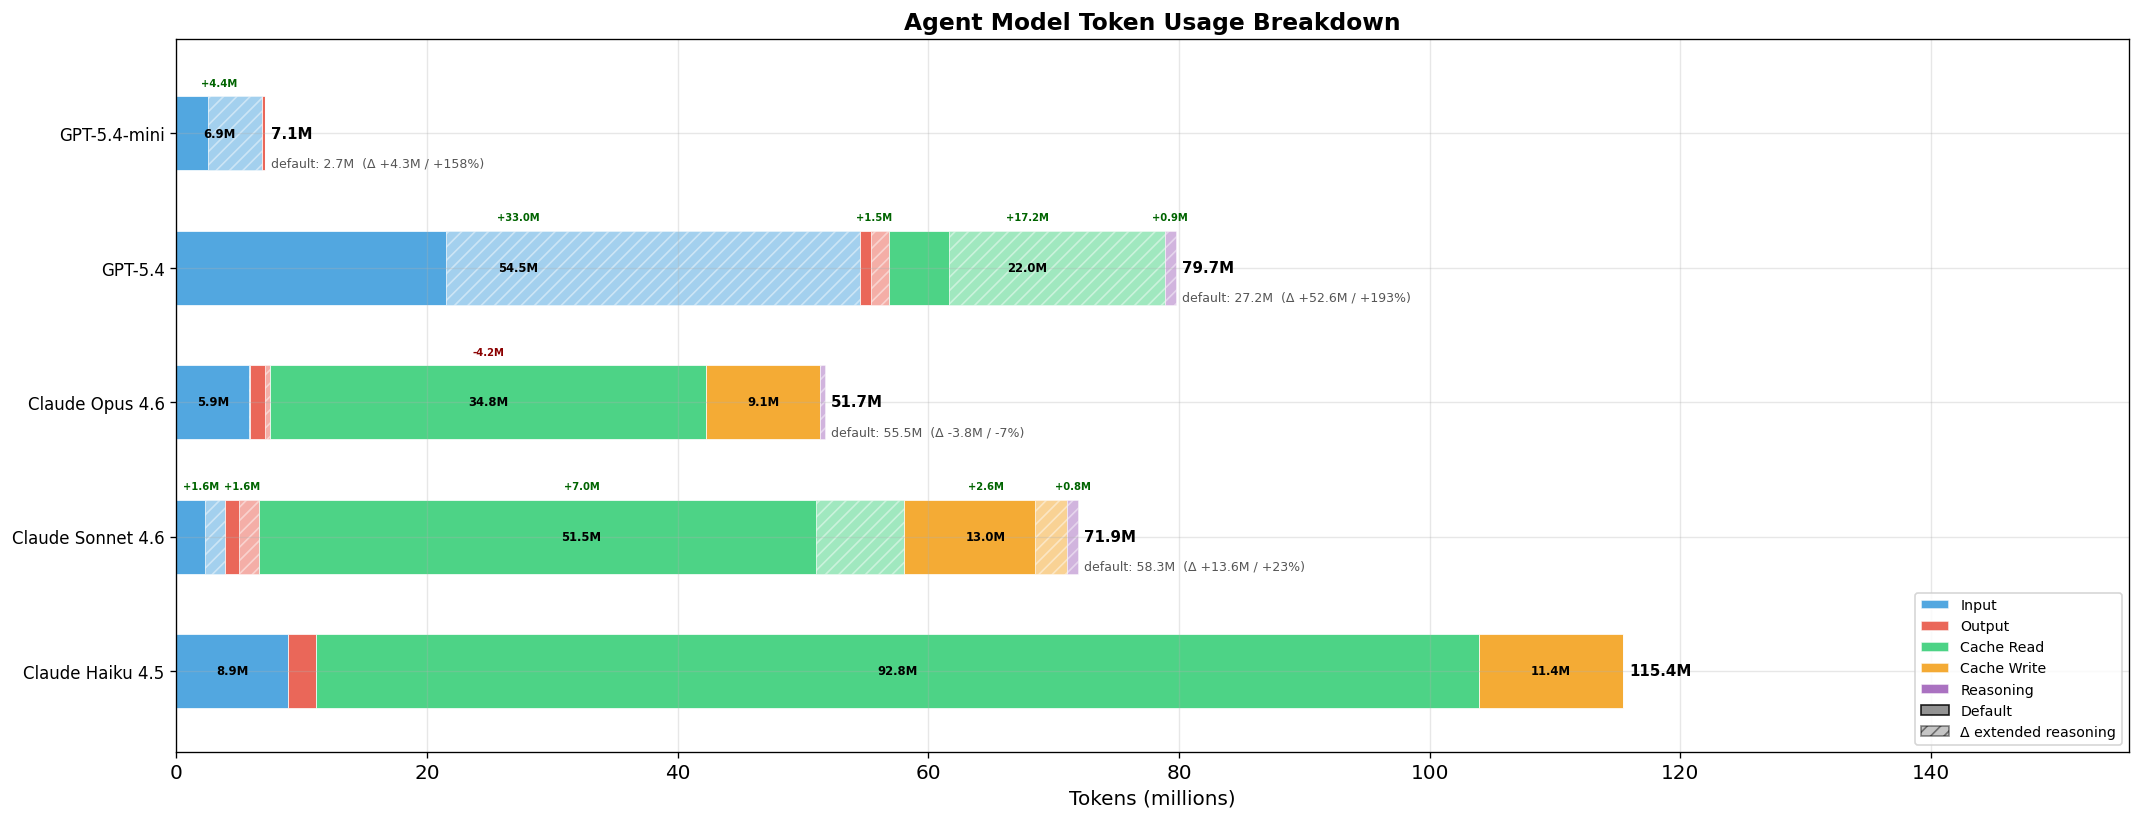

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Token usage stacked horizontal bars
# ══════════════════════════════════════════════════════════════════════════════
categories = ['Input', 'Output', 'Cache Read', 'Cache Write', 'Reasoning']
cat_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
token_keys = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens']

fig, ax = plt.subplots(figsize=(18, max(5, len(MODEL_ORDER) * 1.4)))
bar_height = 0.55
all_totals = [sum(cost_df.loc[m][k]/1e6 for k in token_keys) for m in MODEL_ORDER]
global_max = max(all_totals)
MIN_LABEL_WIDTH = global_max * 0.05

for i, m in enumerate(MODEL_ORDER):
    row = cost_df.loc[m]
    vals = [row[k]/1e6 for k in token_keys]
    has_baseline = m in baseline_cost_df.index
    bvals = [baseline_cost_df.loc[m][k]/1e6 for k in token_keys] if has_baseline else vals

    left = 0
    for j, (rv, bv, c) in enumerate(zip(vals, bvals, cat_colors)):
        if has_baseline and rv > 0:
            solid_w = min(rv, bv)
            delta_w = rv - bv
            ax.barh(i, solid_w, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
            if delta_w > 0.01:
                ax.barh(i, delta_w, left=left + solid_w, height=bar_height, color=c,
                        edgecolor='white', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.barh(i, rv, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
        if rv >= MIN_LABEL_WIDTH:
            ax.text(left + rv/2, i, f'{rv:.1f}M', ha='center', va='center', fontsize=7, fontweight='bold')
        if has_baseline and abs(rv - bv) > 0.4:
            ax.text(left + rv/2, i + bar_height/2 + 0.06, f'{rv - bv:+.1f}M', ha='center', va='bottom',
                    fontsize=6, fontweight='bold', color='#006400' if rv > bv else '#8B0000')
        left += rv

    total_m = sum(vals)
    ax.text(left + 0.5, i, f'{total_m:.1f}M', va='center', ha='left', fontsize=9, fontweight='bold')
    if has_baseline:
        base_total = sum(bvals)
        ax.text(left + 0.5, i - 0.22,
                f'default: {base_total:.1f}M  (Δ {total_m - base_total:+.1f}M / {(total_m - base_total)/base_total*100:+.0f}%)',
                va='center', ha='left', fontsize=7.5, fontstyle='italic', color='#555')

ax.set_yticks(range(len(MODEL_ORDER))); ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_xlabel('Tokens (millions)'); ax.set_title('Agent Model Token Usage Breakdown', fontweight='bold')
ax.set_xlim(right=global_max * 1.35); ax.set_ylim(-0.6, len(MODEL_ORDER) - 0.3)

legend_handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=cat) for cat, c in zip(categories, cat_colors)]
legend_handles += [mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'token_usage_breakdown.png', bbox_inches='tight')
plt.show()

---

## 5. Cost Efficiency: Reward per Dollar

$$\text{Cost Efficiency} = \frac{\text{Mean SABER Score}}{\text{Total Cost (\$)}}$$

Higher = better value. The most cost-efficient model is not always the highest-scoring one.

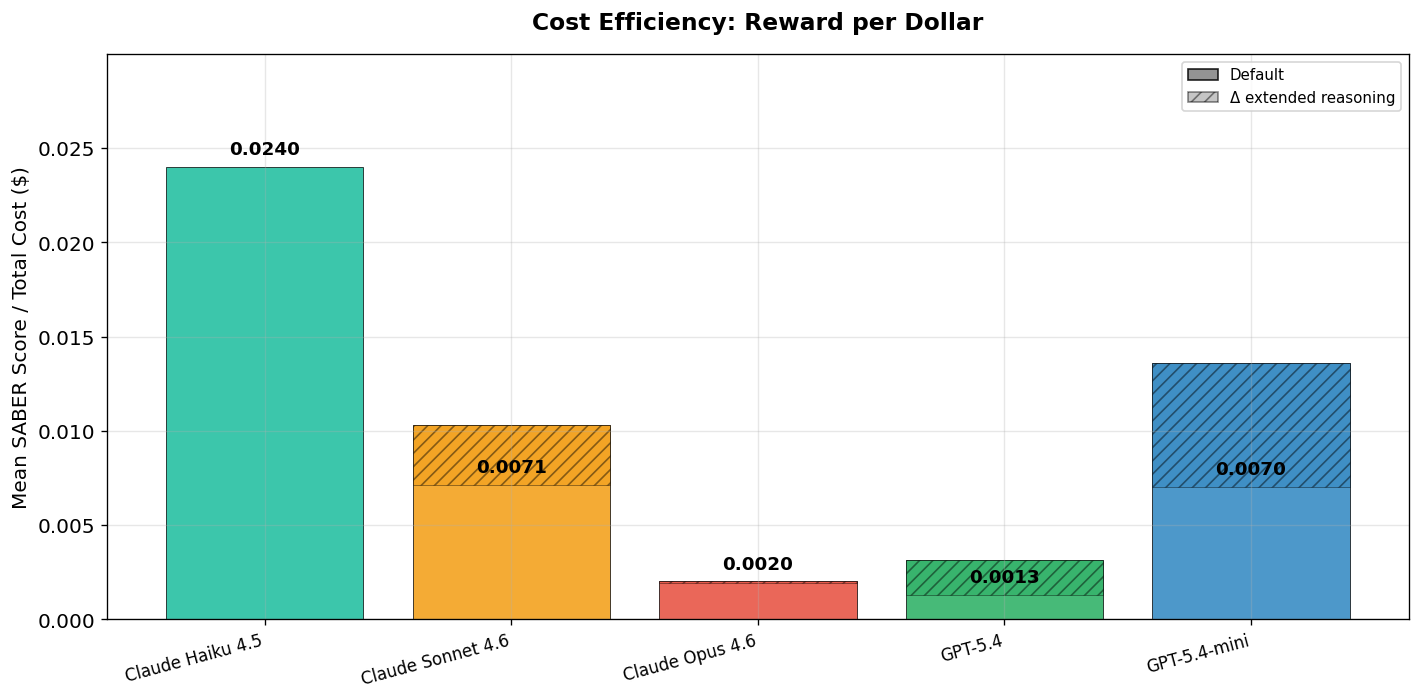

═══ Cost Efficiency Summary ═══
Model                      Score     Cost   $/sample    Score/$
────────────────────────────────────────────────────────────
Claude Haiku 4.5           0.838 $  34.95 $   0.0584    0.02398
Claude Sonnet 4.6          0.857 $ 120.48 $   0.2011    0.00711
Claude Opus 4.6            0.865 $ 441.78 $   0.7375    0.00196
GPT-5.4                    0.875 $ 671.79 $   1.1215    0.00130
GPT-5.4-mini               0.827 $ 117.78 $   0.1966    0.00702


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Cost efficiency — reward per dollar
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

reward_per_dollar = cost_df['score'] / cost_df['total_cost']
baseline_rpd = baseline_cost_df['score'] / baseline_cost_df['total_cost'] if len(baseline_cost_df) > 0 else pd.Series(dtype=float)

for i, m in enumerate(MODEL_ORDER):
    rpd_val = reward_per_dollar[m]
    if m in baseline_rpd.index:
        base_rpd = baseline_rpd[m]
        ax.bar(i, base_rpd, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        delta_rpd = rpd_val - base_rpd
        ax.bar(i, abs(delta_rpd), bottom=base_rpd if delta_rpd > 0 else rpd_val,
               color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, rpd_val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, rpd_val + reward_per_dollar.max()*0.02, f'{rpd_val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score / Total Cost ($)')
ax.set_title('Cost Efficiency: Reward per Dollar', fontweight='bold', pad=15)
ax.set_ylim(0, reward_per_dollar.max() * 1.25)
solid_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default')
hatch_patch = mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')
ax.legend(handles=[solid_patch, hatch_patch], loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Cost Efficiency Summary ═══')
print(f'{"Model":25s} {"Score":>6s} {"Cost":>8s} {"$/sample":>10s} {"Score/$":>10s}')
print('─' * 60)
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    rpd = row['score'] / row['total_cost']
    print(f'{m:25s} {row["score"]:6.3f} ${row["total_cost"]:7.2f} ${row["cost_per_sample"]:9.4f} {rpd:10.5f}')

---

## 6. Sub-Task Score Breakdown

### What this measures

Each task produces three score types:
- **Submission** — final answer correctness (LLM-judge or static match)
- **Checkpoints** — intermediate investigative steps (varies: 2 for Excytin, 5 for CTI Realm, 6 for CyBench)
- **Aggregate** — weighted combination feeding into `saber_overall`

A model with high submission but low checkpoints may be guessing — risky for production.

═══ Sub-Task Mean Scores (with extended reasoning) ═══
category           Submission  Checkpoints  Aggregate
model                                                
Claude Haiku 4.5       0.6795       0.2374     0.8381
Claude Sonnet 4.6      0.7045       0.2185     0.8567
Claude Opus 4.6        0.7563       0.2028     0.8649
GPT-5.4                0.6828       0.2709     0.8752
GPT-5.4-mini           0.7179       0.2489     0.8265


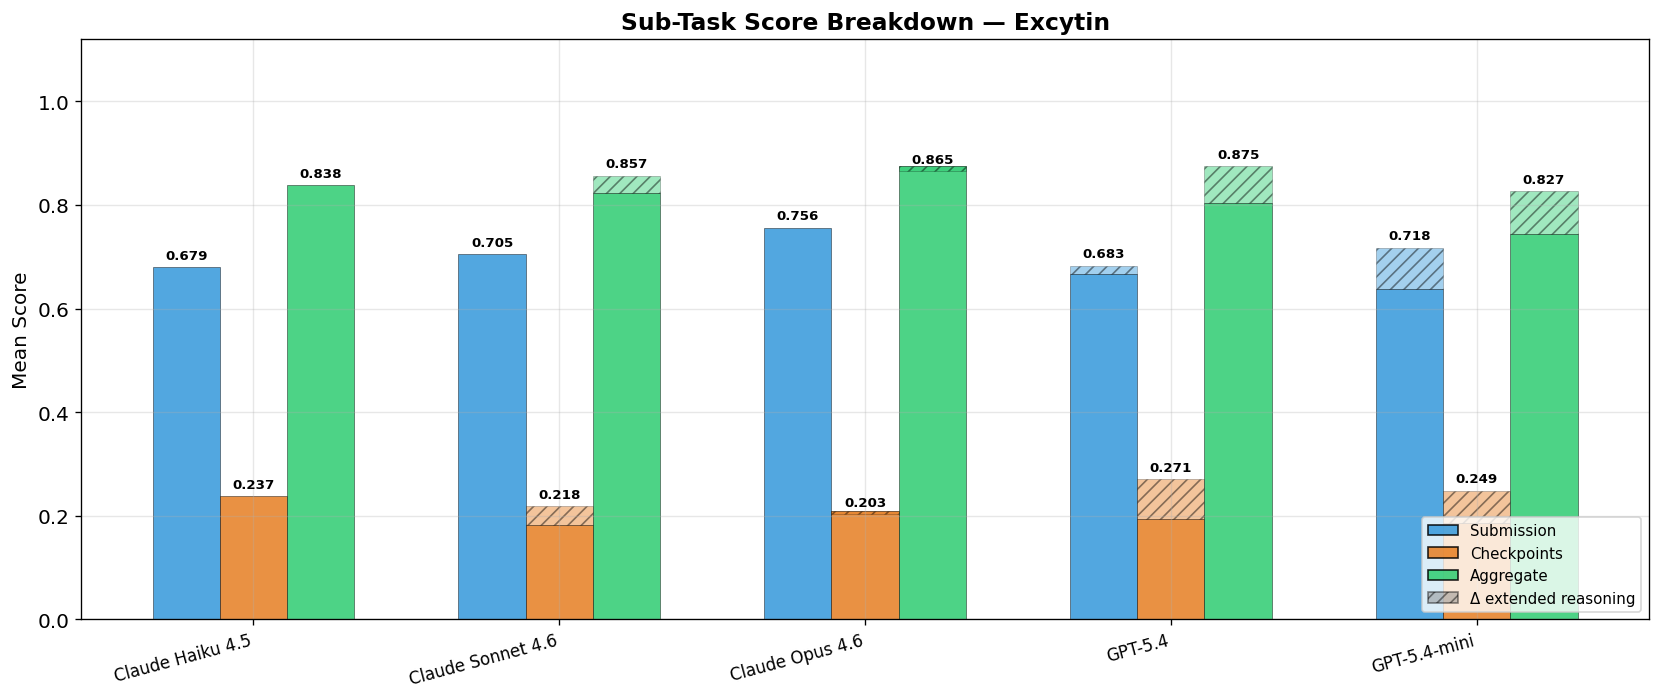

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Sub-task breakdown — Submission vs Checkpoints vs Aggregate
# ══════════════════════════════════════════════════════════════════════════════
subtasks_df['category'] = subtasks_df['score_type'].apply(classify_score_type)
cat_means = subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
available_cats = [c for c in ['Submission', 'Checkpoints', 'Aggregate'] if c in cat_means.columns]
cat_means = cat_means.reindex(MODEL_ORDER)[available_cats]

baseline_cat_means = pd.DataFrame()
if len(baseline_subtasks_df) > 0:
    baseline_subtasks_df['category'] = baseline_subtasks_df['score_type'].apply(classify_score_type)
    baseline_cat_means = baseline_subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
    baseline_cat_means = baseline_cat_means.reindex(columns=available_cats)

print('═══ Sub-Task Mean Scores (with extended reasoning) ═══')
print(cat_means.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
cat_plot_colors = ['#3498DB', '#E67E22', '#2ECC71'][:len(available_cats)]
x = np.arange(len(MODEL_ORDER))
bar_width = 0.22

for j, (cat, color) in enumerate(zip(available_cats, cat_plot_colors)):
    offset = (j - len(available_cats)/2 + 0.5) * bar_width
    for i, m in enumerate(MODEL_ORDER):
        full_val = cat_means.loc[m, cat]
        has_base = (len(baseline_cat_means) > 0 and m in baseline_cat_means.index
                    and not pd.isna(baseline_cat_means.loc[m, cat]) if cat in baseline_cat_means.columns else False)
        if has_base:
            base_val = baseline_cat_means.loc[m, cat]
            ax.bar(x[i] + offset, base_val, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
            d = full_val - base_val
            if abs(d) > 0.001:
                ax.bar(x[i] + offset, abs(d), bottom=base_val if d > 0 else full_val,
                       width=bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
        else:
            ax.bar(x[i] + offset, full_val, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
        ax.text(x[i] + offset, full_val + 0.01, f'{full_val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

cat_handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.85, label=cat) for cat, c in zip(available_cats, cat_plot_colors)]
cat_handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
ax.legend(handles=cat_handles, fontsize=9, loc='lower right')
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean Score')
ax.set_title(f'Sub-Task Score Breakdown — {DOMAIN_NAME}', fontweight='bold')
ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'subtask_breakdown.png', bbox_inches='tight')
plt.show()

---

## 7. Checkpoint Score Distributions

Violin plots showing the **full distribution** of checkpoint scores per model. Wide regions = many samples clustered at that score level.

- Bimodal distributions (two peaks) = model either nails it or fails completely
- Tight distributions = consistent performance

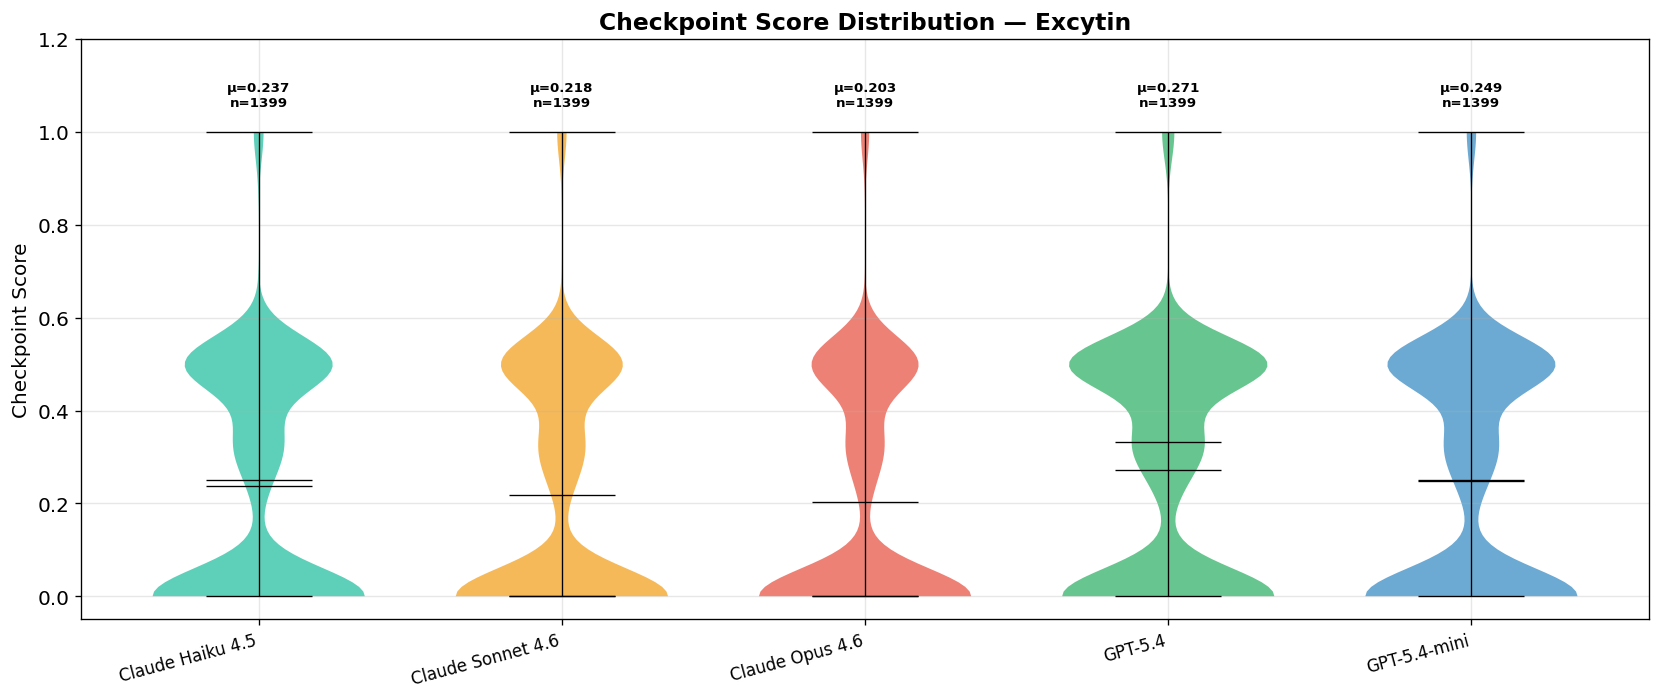

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Checkpoint score distributions (violin plot)
# ══════════════════════════════════════════════════════════════════════════════
checkpoint_df = subtasks_df[subtasks_df['score_type'].str.startswith('checkpoint')].copy()

fig, ax = plt.subplots(figsize=(14, 6))
positions, tick_labels = [], []

for i, model in enumerate(MODEL_ORDER):
    data = checkpoint_df[checkpoint_df['model'] == model]['score'].values
    if len(data) == 0:
        continue
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']:
        pc.set_facecolor(COLORS[model])
        pc.set_alpha(0.7)
    for part in ('cmaxes', 'cmins', 'cbars', 'cmeans', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor('black')
            vp[part].set_linewidth(0.8)
    ax.text(i, 1.05, f'μ={np.mean(data):.3f}\nn={len(data)}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    positions.append(i)
    tick_labels.append(model)

ax.set_xticks(positions); ax.set_xticklabels(tick_labels, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Checkpoint Score')
ax.set_title(f'Checkpoint Score Distribution — {DOMAIN_NAME}', fontweight='bold')
ax.set_ylim(-0.05, 1.2)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_distributions.png', bbox_inches='tight')
plt.show()

---

## Next Steps

### Domain-specific experiments

Experiment 2 (Per-Group Breakdown) in this notebook is domain-specific — it requires a `GROUP_FN` tailored to each domain. For additional domain-specific analysis beyond per-group breakdown:
- **Excytin:** [`excytin_analysis.ipynb`](excytin_analysis.ipynb) — per-incident submission vs. checkpoint gap heatmap

### Adding your own models

1. Run: `uv run inspect eval domains/<domain> --model <model_id>`
2. Copy the `.eval` file to `latest_experiments/<domain>/`
3. Edit the **Configuration cell** above
4. Re-run the notebook

### Switching domains

To analyze a different domain, change three things in the Configuration cell:
1. `DOMAIN_NAME`, `LOG_DIR` — point to the domain's logs
2. `EVAL_LOGS` / `COLORS` / `PRICING` — your models for that domain
3. `GROUP_FN` / `GROUP_LABEL` — build a grouping function for the domain's task structure

### Further reading

- **[README.md](../README.md)** — Installation, domains, agents, CLI
- `uv run inspect view` — Interactive log viewer